In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

In [2]:
NASDQ = pd.read_csv("NASDAQ100_Historical_Data.csv")
NASDQ

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2000-01-03,0.94,1.00,0.91,1.00,0.84,535796800
1,AAPL,2000-01-04,0.97,0.99,0.90,0.92,0.77,512377600
2,AAPL,2000-01-05,0.93,0.99,0.92,0.93,0.78,778321600
3,AAPL,2000-01-06,0.95,0.96,0.85,0.85,0.71,767972800
4,AAPL,2000-01-07,0.86,0.90,0.85,0.89,0.75,460734400
...,...,...,...,...,...,...,...,...
514070,ZS,2026-02-11,175.62,175.87,165.36,171.00,171.00,2670100
514071,ZS,2026-02-12,171.99,173.99,163.00,170.90,170.90,2499300
514072,ZS,2026-02-13,174.34,179.90,172.43,177.72,177.72,2434100
514073,ZS,2026-02-17,175.82,176.85,169.61,172.59,172.59,2038100


In [3]:
print(type(NASDQ))

<class 'pandas.core.frame.DataFrame'>


In [4]:
NASDQ.isna().sum()

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [5]:
NASDQ.duplicated().sum()

np.int64(0)

In [6]:
col=NASDQ.columns
col

Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close',
       'Volume'],
      dtype='object')

In [7]:
NASDQ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514075 entries, 0 to 514074
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Ticker     514075 non-null  object 
 1   Date       514075 non-null  object 
 2   Open       514075 non-null  float64
 3   High       514075 non-null  float64
 4   Low        514075 non-null  float64
 5   Close      514075 non-null  float64
 6   Adj Close  514075 non-null  float64
 7   Volume     514075 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 31.4+ MB


In [8]:
NASDQ['Ticker'].unique()

array(['AAPL', 'ABNB', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'AMAT', 'AMD',
       'AMGN', 'AMZN', 'APP', 'ARM', 'ASML', 'AVGO', 'AZN', 'BIIB',
       'BKNG', 'BKR', 'CCEP', 'CDNS', 'CDW', 'CEG', 'CHTR', 'CMCSA',
       'COIN', 'COST', 'CPRT', 'CRWD', 'CSGP', 'CTAS', 'CTSH', 'DASH',
       'DDOG', 'DLTR', 'DXCM', 'EA', 'EXC', 'FANG', 'FAST', 'FTNT',
       'GEHC', 'GFS', 'GILD', 'GOOG', 'GOOGL', 'HON', 'IDXX', 'INTC',
       'INTU', 'ISRG', 'KDP', 'KHC', 'KLAC', 'LIN', 'LRCX', 'LULU', 'MAR',
       'MCHP', 'MDB', 'MDLZ', 'MELI', 'META', 'MNST', 'MRNA', 'MRVL',
       'MSFT', 'MU', 'NFLX', 'NVDA', 'NXPI', 'ODFL', 'ON', 'ORLY', 'PANW',
       'PAYX', 'PCAR', 'PDD', 'PEP', 'PLTR', 'PYPL', 'QCOM', 'REGN',
       'ROP', 'ROST', 'SBUX', 'SMCI', 'SNPS', 'TEAM', 'TMUS', 'TSLA',
       'TTD', 'TTWO', 'TXN', 'VRSK', 'VRTX', 'WBD', 'WDAY', 'XEL', 'ZS'],
      dtype=object)

In [9]:
NASDQ['Ticker'].nunique()

100

In [10]:
NASDQ.describe()

,Open,High,Low,Close,Adj Close,Volume
count,514075.000000,514075.000000,514075.000000,514075.000000,514075.000000,5.140750e+05
mean,100.179428,101.486198,98.834356,100.186068,94.683734,2.596485e+07
std,241.284690,244.184916,238.271945,241.291633,239.893928,1.087908e+08
min,0.030000,0.030000,0.030000,0.030000,0.030000,0.000000e+00
25%,17.990000,18.270000,17.700000,17.990000,13.800000,1.653700e+06
50%,40.770000,41.320000,40.240000,40.800000,32.760000,3.758500e+06
75%,96.820000,98.040000,95.580000,96.850000,89.660000,1.056520e+07
max,5815.000000,5839.410000,5707.930000,5815.920000,5794.840000,9.230856e+09


In [11]:
NASDQ['Date'] = pd.to_datetime(NASDQ['Date'])

In [12]:
NASDQ.dtypes

Ticker               object
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

In [13]:
NASDQ

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2000-01-03,0.94,1.00,0.91,1.00,0.84,535796800
1,AAPL,2000-01-04,0.97,0.99,0.90,0.92,0.77,512377600
2,AAPL,2000-01-05,0.93,0.99,0.92,0.93,0.78,778321600
3,AAPL,2000-01-06,0.95,0.96,0.85,0.85,0.71,767972800
4,AAPL,2000-01-07,0.86,0.90,0.85,0.89,0.75,460734400
...,...,...,...,...,...,...,...,...
514070,ZS,2026-02-11,175.62,175.87,165.36,171.00,171.00,2670100
514071,ZS,2026-02-12,171.99,173.99,163.00,170.90,170.90,2499300
514072,ZS,2026-02-13,174.34,179.90,172.43,177.72,177.72,2434100
514073,ZS,2026-02-17,175.82,176.85,169.61,172.59,172.59,2038100


In [14]:
NASDQ.isna().sum()

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [15]:
columns = NASDQ.columns
columns

Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close',
       'Volume'],
      dtype='object')

## Finding outliers

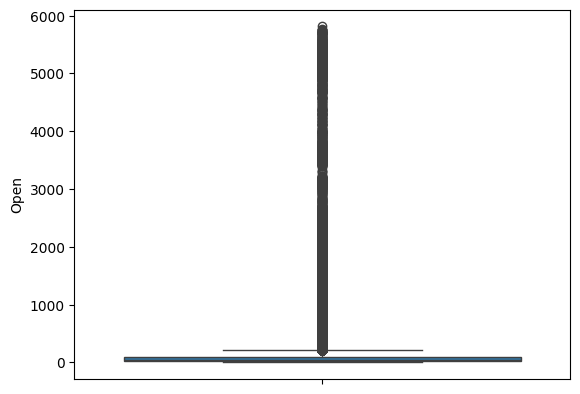

In [16]:
sns.boxplot(NASDQ['Open'])
plt.show()

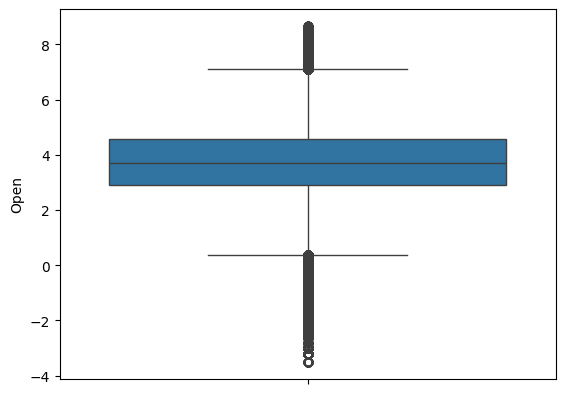

In [17]:
sns.boxplot(y=np.log(NASDQ['Open']))
plt.show()

In [18]:
## blue box - normal price range
## lines - min & max (without outliers)
## Black dots - outliers(very high or very low)

# closing price trend

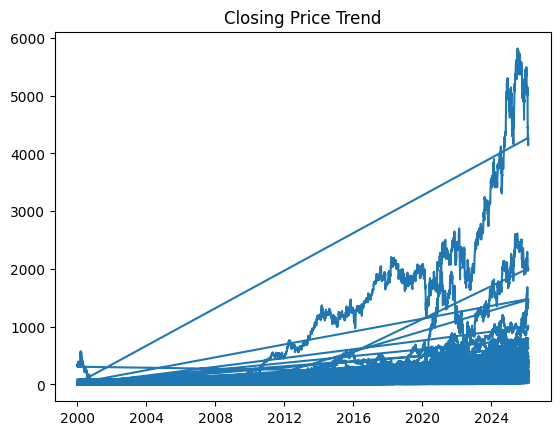

In [19]:
plt.plot(NASDQ['Date'], NASDQ['Close'])
plt.title("Closing Price Trend")
plt.show()

# Moving average

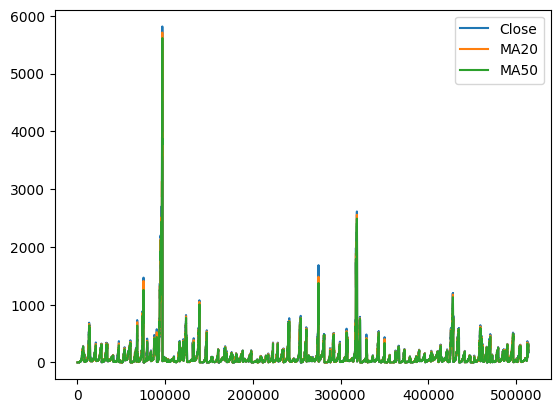

In [20]:
NASDQ['MA20'] = NASDQ['Close'].rolling(20).mean()     #MA20 means take last 20 days closing price and calculate average # short term
NASDQ['MA50'] = NASDQ['Close'].rolling(50).mean()     #MA50 means take last 50 days closing price and calculate average  # medium term and MA200 Long term

plt.plot(NASDQ['Close'])
plt.plot(NASDQ['MA20'])
plt.plot(NASDQ['MA50'])
plt.legend(['Close','MA20','MA50'])
plt.show()

# Volume trend

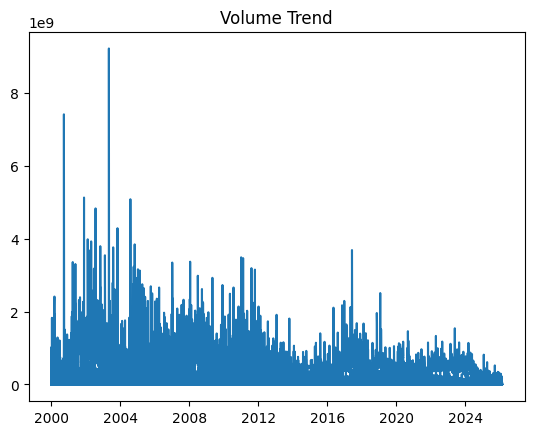

In [21]:
plt.plot(NASDQ['Date'], NASDQ['Volume'])
plt.title("Volume Trend")
plt.show()

# Feature engineering (technical indicators)

# step 1 ---> Moving Average Crossover Signal

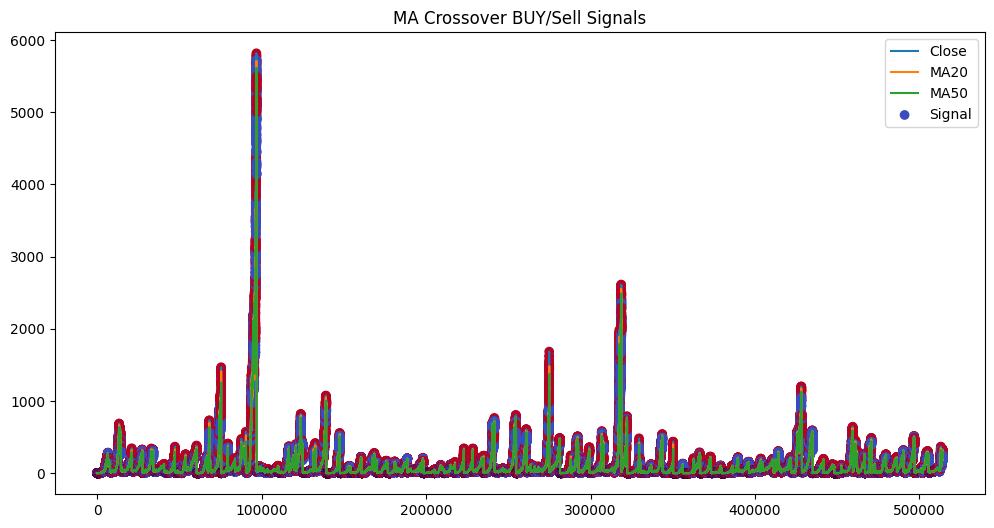

In [22]:
NASDQ['MA20'] = NASDQ['Close'].rolling(20).mean()
NASDQ['MA50'] = NASDQ['Close'].rolling(50).mean()

NASDQ['Signal'] = 0
NASDQ.loc[NASDQ['MA20'] > NASDQ['MA50'],'Signal'] = 1  # Buy
NASDQ.loc[NASDQ['MA50'] < NASDQ['MA50'],'Signal'] = -1  # Sell

plt.figure(figsize=(12,6))
plt.plot(NASDQ['Close'], label='Close')
plt.plot(NASDQ['MA20'], label='MA20')
plt.plot(NASDQ['MA50'], label='MA50')

plt.scatter(NASDQ.index, NASDQ['Close'],
            c=NASDQ['Signal'],
            cmap='coolwarm', label='Signal')

plt.legend()
plt.title("MA Crossover BUY/Sell Signals")
plt.show()

# step 2 -----> RSI (Relative Strength Index)

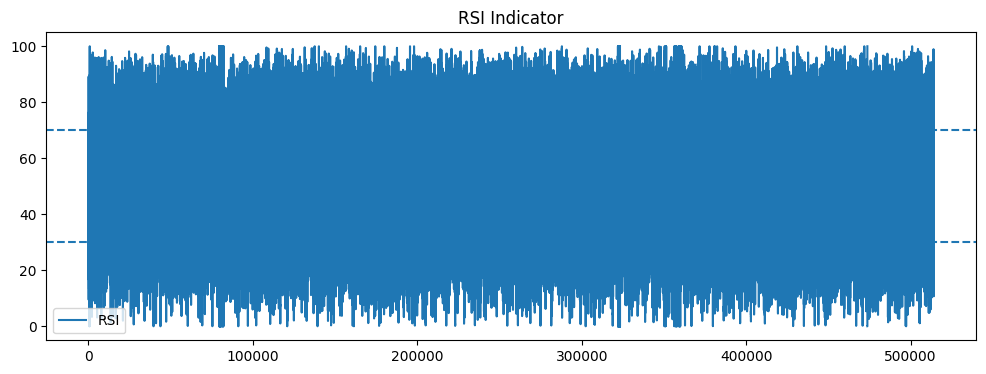

In [23]:
delta = NASDQ['Close'].diff()

gain = (delta.where(delta > 0,0)).rolling(14).mean()
loss = (-delta.where(delta < 0,0)).rolling(14).mean()

rs = gain/loss
NASDQ['RSI'] = 100 - (100/(1+rs))

plt.figure(figsize=(12,4))
plt.plot(NASDQ['RSI'], label='RSI')
plt.axhline(70, linestyle='--') # Overbought
plt.axhline(30, linestyle='--') # Oversold
plt.legend()
plt.title("RSI Indicator")
plt.show()

# RSI>70--> Overbought(Sell)
# RSI<30--> Oversold(Buy)

# step 3 ---> MACD Indicator

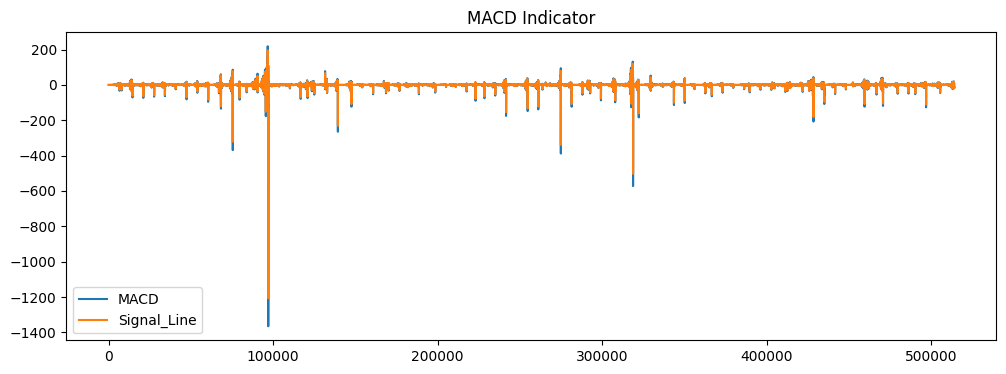

In [24]:
exp1 = NASDQ['Close'].ewm(span=12,adjust=False).mean()
exp2 = NASDQ['Close'].ewm(span=26,adjust=False).mean()

NASDQ['MACD'] = exp1 - exp2
NASDQ['Signal_Line'] = NASDQ['MACD'].ewm(span=9,adjust=False).mean()

plt.figure(figsize=(12,4))
plt.plot(NASDQ['MACD'], label='MACD')
plt.plot(NASDQ['Signal_Line'],label='Signal_Line')
plt.legend()
plt.title("MACD Indicator")
plt.show()

# MACD>Signal-->Buy
# MACD<Signal-->Sell

# step 4 ---> Correlation Heatmap(Multiple Stocks)

[*********************100%***********************]  100 of 100 completed


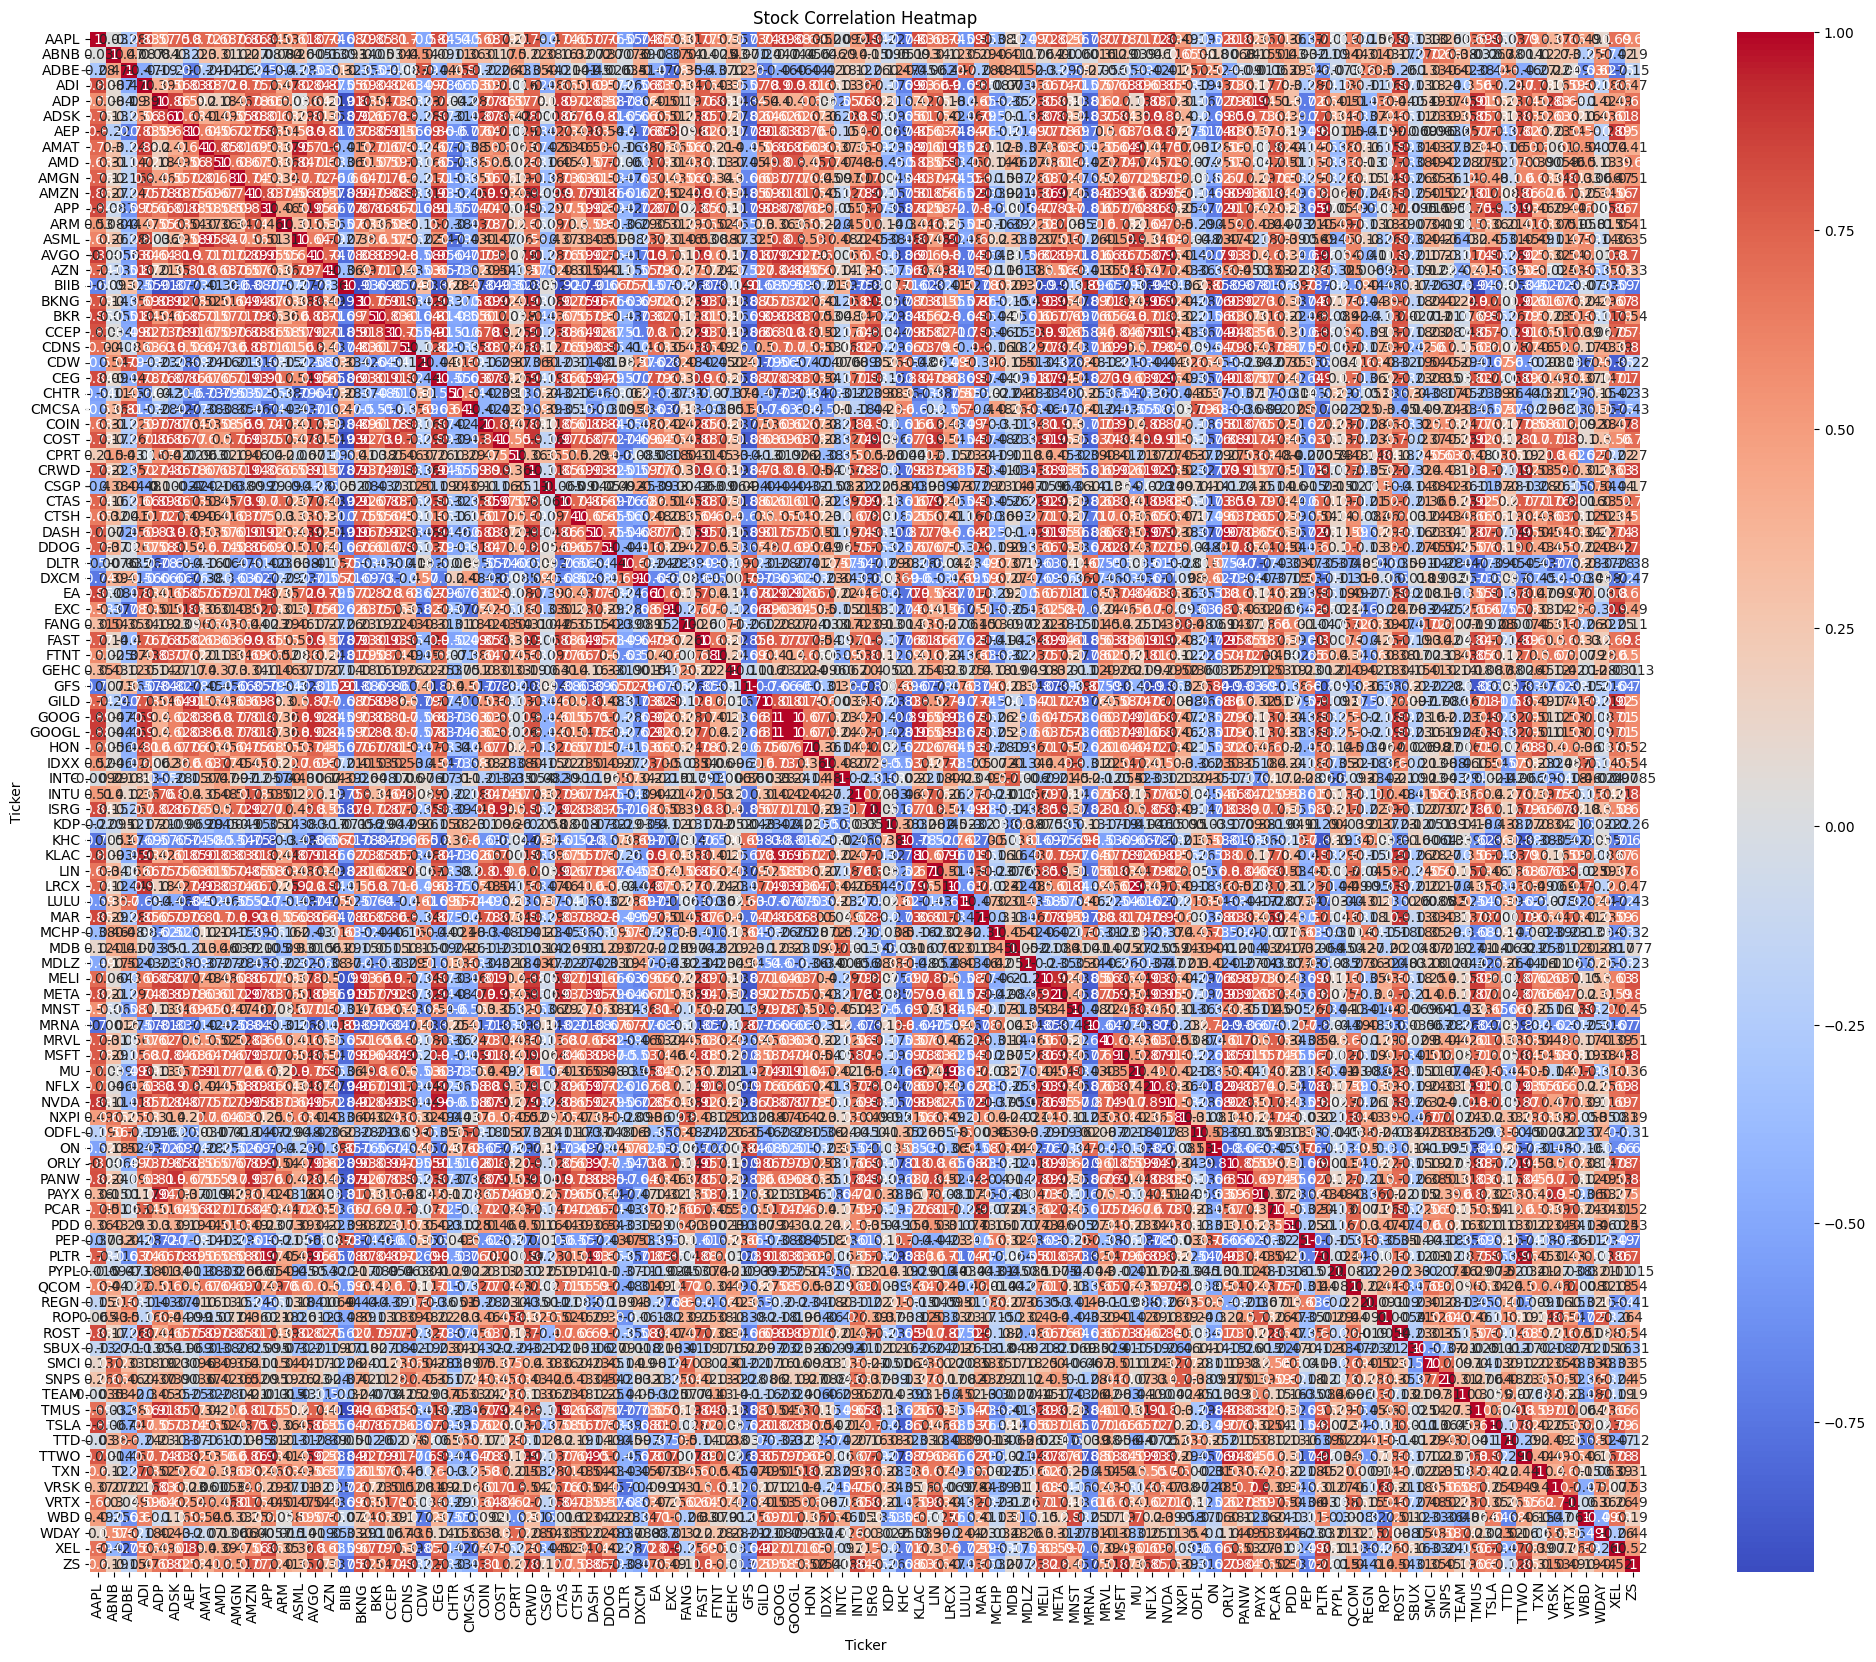

In [31]:
NASDQ =['AAPL', 'ABNB', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'AMAT', 'AMD',
       'AMGN', 'AMZN', 'APP', 'ARM', 'ASML', 'AVGO', 'AZN', 'BIIB',
       'BKNG', 'BKR', 'CCEP', 'CDNS', 'CDW', 'CEG', 'CHTR', 'CMCSA',
       'COIN', 'COST', 'CPRT', 'CRWD', 'CSGP', 'CTAS', 'CTSH', 'DASH',
       'DDOG', 'DLTR', 'DXCM', 'EA', 'EXC', 'FANG', 'FAST', 'FTNT',
       'GEHC', 'GFS', 'GILD', 'GOOG', 'GOOGL', 'HON', 'IDXX', 'INTC',
       'INTU', 'ISRG', 'KDP', 'KHC', 'KLAC', 'LIN', 'LRCX', 'LULU', 'MAR',
       'MCHP', 'MDB', 'MDLZ', 'MELI', 'META', 'MNST', 'MRNA', 'MRVL',
       'MSFT', 'MU', 'NFLX', 'NVDA', 'NXPI', 'ODFL', 'ON', 'ORLY', 'PANW',
       'PAYX', 'PCAR', 'PDD', 'PEP', 'PLTR', 'PYPL', 'QCOM', 'REGN',
       'ROP', 'ROST', 'SBUX', 'SMCI', 'SNPS', 'TEAM', 'TMUS', 'TSLA',
       'TTD', 'TTWO', 'TXN', 'VRSK', 'VRTX', 'WBD', 'WDAY', 'XEL', 'ZS']
data= yf.download(NASDQ,start='2023-01-01')['Close']

corr = data.corr()
plt.figure(figsize=(25,20))
sns.heatmap(corr, annot=True,cmap='coolwarm')
plt.title("Stock Correlation Heatmap")
plt.show()

# step 5 ---> Volatility (Risk Analysis)

In [26]:
returns = data.pct_change()
volatility = returns.std()
volatility_percent = volatility*100
print("Volatility:",volatility_percent)

# High volatility --> High risk
# Low volatility --> Stable stock

Volatility: Ticker
AAPL    1.619864
ABNB    2.389889
ADBE    2.107691
ADI     2.058142
ADP     1.230349
          ...   
VRTX    1.776616
WBD     3.401548
WDAY    2.154633
XEL     1.291633
ZS      2.923504
Length: 100, dtype: float64


In [27]:
mean_returns = returns.mean()
mean_returns

Ticker
AAPL    0.001097
ABNB    0.000872
ADBE   -0.000091
ADI     0.001268
ADP     0.000029
          ...   
VRTX    0.000861
WBD     0.001939
WDAY   -0.000065
XEL     0.000434
ZS      0.000796
Length: 100, dtype: float64

In [28]:
risk = returns.std()
risk

Ticker
AAPL    0.016199
ABNB    0.023899
ADBE    0.021077
ADI     0.020581
ADP     0.012303
          ...   
VRTX    0.017766
WBD     0.034015
WDAY    0.021546
XEL     0.012916
ZS      0.029235
Length: 100, dtype: float64

In [29]:
# find best automatically 

best_stock = (mean_returns / risk).idxmax()
print("Best Stock:", best_stock)

Best Stock: APP
